In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#read the train and test data
test = pd.read_csv('/content/drive/MyDrive/Fake_reviews/Yelp NYC Metadata.csv') #train data
train = pd.read_csv('/content/drive/MyDrive/Fake_reviews/yelp.csv') #test data

In [ ]:
#check the head of train data
train.head()

,Review_id,Product_id,Date,Review
0,923,0,12/8/2014,The food at snack is a selection of popular Gr...
1,924,0,5/16/2013,This little place in Soho is wonderful. I had ...
2,925,0,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...
3,926,0,7/28/2011,This is a beautiful quaint little restaurant o...
4,927,0,11/1/2010,Snack is great place for a Â casual sit down l...


In [ ]:
#check the head of train data
test.head()


,Product_id,Product_id2,Rating,Label,Date
0,923,0,3,-1,12/8/2014
1,924,0,3,-1,5/16/2013
2,925,0,4,-1,7/1/2013
3,926,0,4,-1,7/28/2011
4,927,0,4,-1,11/1/2010


In [ ]:
#check the shape of the given dataset
print(f'train has {train.shape[0]} number of rows and {train.shape[1]} number of columns')
print(f'train has {test.shape[0]} number of rows and {test.shape[1]} number of columns')

train has 359052 number of rows and 4 number of columns
train has 359052 number of rows and 5 number of columns


In [ ]:


data= pd.DataFrame()

data['User_id'] = train['Review_id']
data['Product_id'] = train['Product_id']
data['Rating'] = test['Rating']
data['Date'] = test['Date']
data['Review'] = train['Review']
data['Label'] = test['Label']
data.head()

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Gr...,-1
1,924,0,3,5/16/2013,This little place in Soho is wonderful. I had ...,-1
2,925,0,4,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...,-1
3,926,0,4,7/28/2011,This is a beautiful quaint little restaurant o...,-1
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down l...,-1


In [ ]:
import pandas as pd

# Assuming your DataFrame is named 'df'
# Replace '-1' with '0' in the 'label' column
data['Label'] = data['Label'].replace(-1, 0)


In [ ]:
data

,User_id,Product_id,Rating,Date,Review,Label
0,923,0,3,12/8/2014,The food at snack is a selection of popular Gr...,0
1,924,0,3,5/16/2013,This little place in Soho is wonderful. I had ...,0
2,925,0,4,7/1/2013,ordered lunch for 15 from Snack last Friday. Â...,0
3,926,0,4,7/28/2011,This is a beautiful quaint little restaurant o...,0
4,927,0,4,11/1/2010,Snack is great place for a Â casual sit down l...,0
...,...,...,...,...,...,...
359047,161146,349,5,2/6/2014,"I'm very spoiled with Pizza. Really, I have tr...",1
359048,116424,349,5,1/31/2014,Can't say enough good things about this place....,1
359049,161147,349,5,1/30/2014,"Had a great dinner here- fantastic pizza, the ...",1
359050,97930,349,5,1/25/2014,"Great foods and great drinks, they have even p...",1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359052 entries, 0 to 359051
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   User_id     359052 non-null  int64 
 1   Product_id  359052 non-null  int64 
 2   Rating      359052 non-null  int64 
 3   Date        359052 non-null  object
 4   Review      359052 non-null  object
 5   Label       359052 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 16.4+ MB


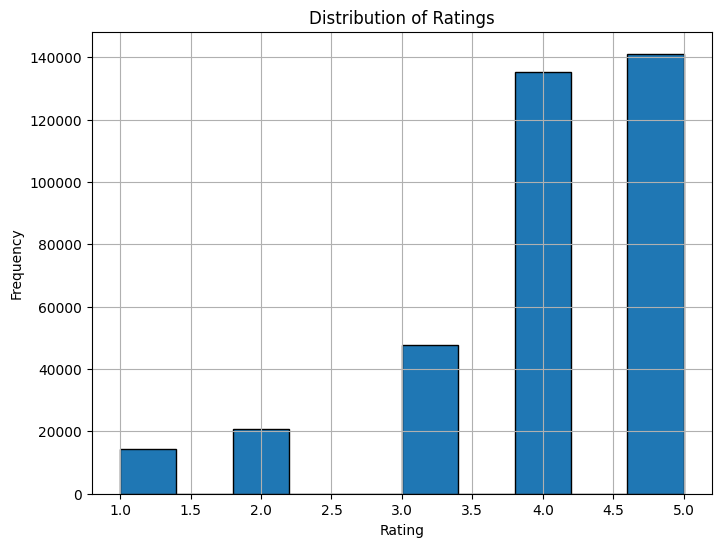

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
plt.hist(data['Rating'], bins=10, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.grid(True)
plt.show()


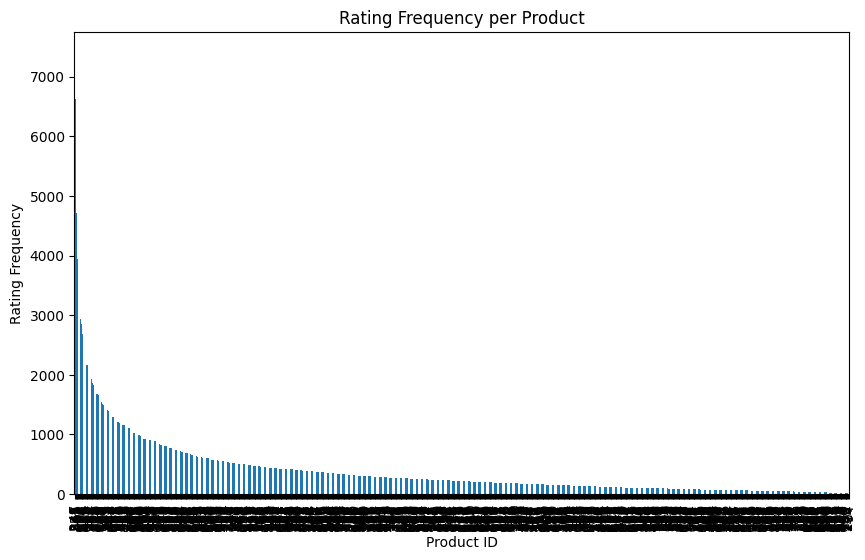

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'df'
# df = ... (your DataFrame)

plt.figure(figsize=(10, 6))
rating_counts = data.groupby('Product_id')['Rating'].count().sort_values(ascending=False)
rating_counts.plot(kind='bar')
plt.xlabel('Product ID')
plt.ylabel('Rating Frequency')
plt.title('Rating Frequency per Product')
plt.show()


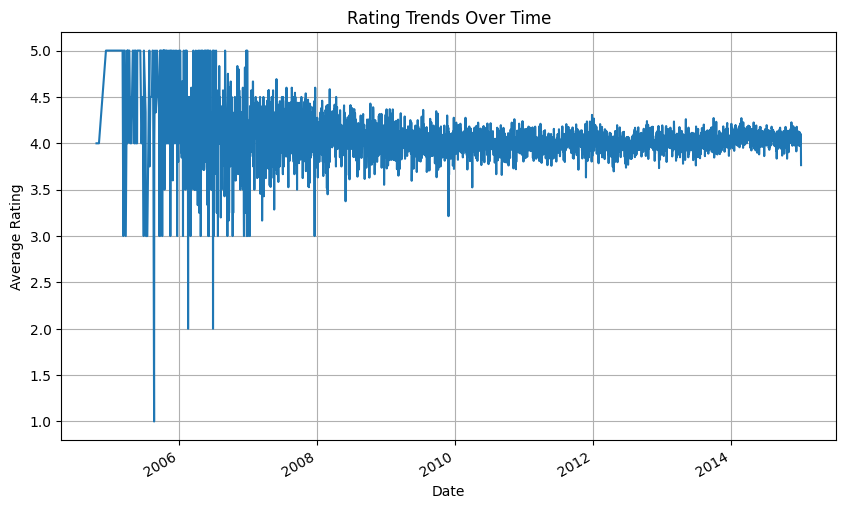

In [ ]:
# Convert 'Date' column to datetime if it's not already in datetime format
data['Date'] = pd.to_datetime(data['Date'])

plt.figure(figsize=(10, 6))
rating_trends = data.groupby('Date')['Rating'].mean()
rating_trends.plot(kind='line')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.title('Rating Trends Over Time')
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
# Separate the data based on classes
class_1_data = data[data['Label'] == 1]
class_minus_1_data = data[data['Label'] == 0]

# Take 40000 samples for class '1' and keep all samples for class '-1'
class_1_sampled = class_1_data.sample(n=40000, random_state=42)

# Concatenate the sampled data with the original data for class '-1'
balanced_data = pd.concat([class_1_sampled, class_minus_1_data])

# Shuffle the balanced data
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the class distribution after balancing
print(balanced_data['Label'].value_counts())


1    40000
0    36885
Name: Label, dtype: int64


In [ ]:
data =balanced_data

In [ ]:
data

,User_id,Product_id,Rating,Date,Review,Label
0,3267,909,4,2014-11-16,Came with friends on a Saturday night-- packed...,1
1,125774,906,3,2010-04-26,Hm...actually I really love their Indian panca...,1
2,153044,854,5,2012-05-02,The food and service are outstanding! Â Does n...,0
3,62307,548,4,2011-07-20,Seeing this place packed during lunch hours ev...,1
4,51878,211,1,2009-11-10,don't believe the hype ! this pizza is horribl...,0
...,...,...,...,...,...,...
76880,68270,724,4,2014-04-21,"I was looking forward to Landmarc, being a fan...",1
76881,85241,417,5,2013-10-28,This is my favorite restaurant in the neighbor...,0
76882,160880,902,5,2012-12-06,The new Benares is a amazing addition to this ...,0
76883,134385,711,1,2014-06-27,I I come to at least 2 to 3 times per month. I...,1


<ipython-input-18-5cbb82a5e968>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = data.corr()


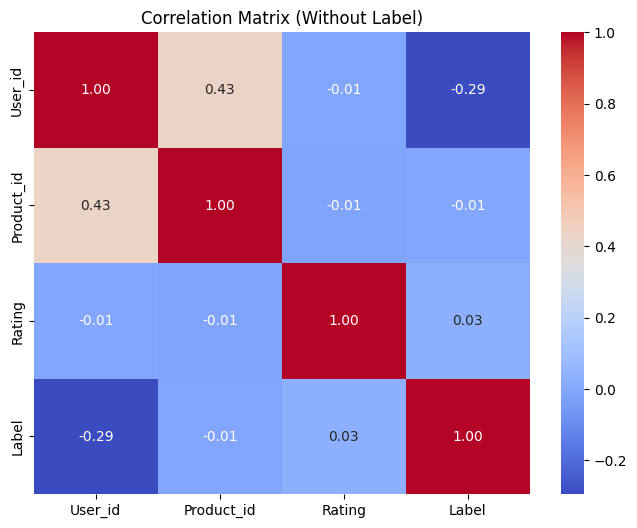

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Calculate the correlation matrix without the 'Label' column
corr_matrix = data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

# Add title and display the plot
plt.title('Correlation Matrix (Without Label)')
plt.show()


In [ ]:
value_counts = data['Label'].value_counts()
print(value_counts)


1    40000
0    36885
Name: Label, dtype: int64


In [ ]:
data.isnull().sum()

User_id       0
Product_id    0
Rating        0
Date          0
Review        0
Label         0
dtype: int64

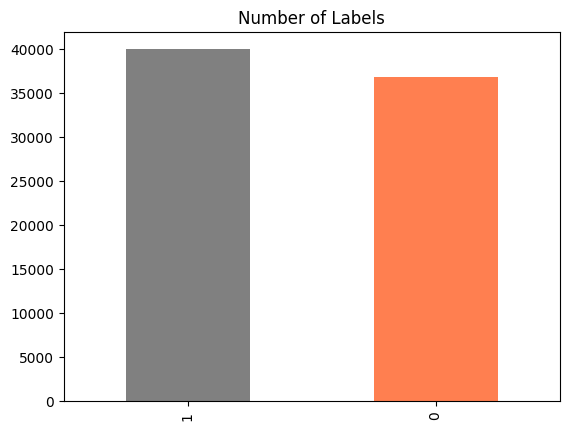

In [ ]:
import matplotlib.pyplot as plt
data["Label"].value_counts().plot(kind = "bar", color=["gray","coral"])
plt.title("Number of Labels")
plt.show()

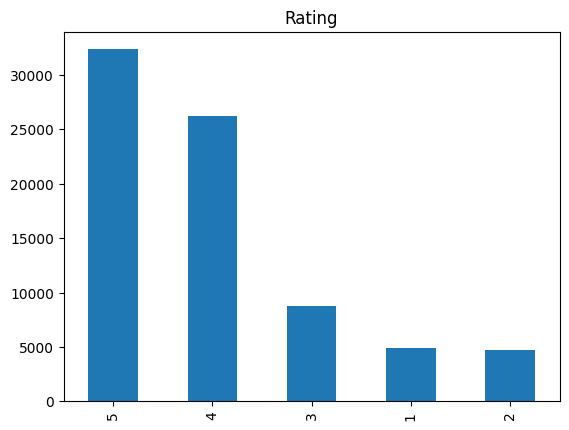

In [ ]:
data["Rating"].value_counts().plot(kind = "bar")#, color=['coral', 'c', 'limegreen', 'gold', 'plum'])
plt.title("Rating")
plt.show()

In [ ]:
x = data.iloc[:,-2]
y = data.iloc[:,-1]


In [ ]:
x

0        Came with friends on a Saturday night-- packed...
1        Hm...actually I really love their Indian panca...
2        The food and service are outstanding! Â Does n...
3        Seeing this place packed during lunch hours ev...
4        don't believe the hype ! this pizza is horribl...
                               ...                        
76880    I was looking forward to Landmarc, being a fan...
76881    This is my favorite restaurant in the neighbor...
76882    The new Benares is a amazing addition to this ...
76883    I I come to at least 2 to 3 times per month. I...
76884    Korean? Check. Cheap? Check. Yummy? Check. Thi...
Name: Review, Length: 76885, dtype: object

In [ ]:
y

0        1
1        1
2        0
3        1
4        0
        ..
76880    1
76881    0
76882    0
76883    1
76884    1
Name: Label, Length: 76885, dtype: int64

# Pre_processing Reviews

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#import the libraries for pre-processing
from bs4 import BeautifulSoup
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

stops = set(stopwords.words('english')) #english stopwords

stemmer = SnowballStemmer('english') #SnowballStemmer

def review_to_words(raw_review):
    # 1. Delete HTML
    review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
    # 2. Make a space
    letters_only = re.sub('[^a-zA-Z]', ' ', review_text)
    # 3. lower letters
    words = letters_only.lower().split()
    # 5. Stopwords
    meaningful_words = [w for w in words if not w in stops]
    # 6. Stemming
    stemming_words = [stemmer.stem(w) for w in meaningful_words]
    # 7. space join words
    return( ' '.join(stemming_words))

In [ ]:
#apply review_to_words function on reviews
merge_df = x.apply(review_to_words)
print(merge_df)

<ipython-input-27-000b24eb6eaf>:14: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  review_text = BeautifulSoup(raw_review, 'html.parser').get_text()


0        came friend saturday night pack seat fair prom...
1        hm actual realli love indian pancak sous yummi...
2        food servic outstand get better limit space ge...
3        see place pack lunch hour everyday know go sol...
4        believ hype pizza horribl crust thick tasteles...
                               ...                        
76880    look forward landmarc fan food network chop ow...
76881    favorit restaur neighborhood right food unreal...
76882    new benar amaz addit neighborhood foodi expect...
76883    come least time per month appauld servic given...
76884    korean check cheap check yummi check review ma...
Name: Review, Length: 76885, dtype: object


# Word2Vec

In [ ]:
import gensim
documents = [_text.split() for _text in merge_df]

In [ ]:
w2v_model = gensim.models.word2vec.Word2Vec(
                                            window=7,
                                            min_count=10,
                                            workers=8)
print(w2v_model)

Word2Vec<vocab=0, vector_size=100, alpha=0.025>


In [ ]:
w2v_model.build_vocab(documents)

In [ ]:
%%time
w2v_model.train(documents, total_examples=len(documents), epochs=5)

CPU times: user 51.8 s, sys: 352 ms, total: 52.1 s
Wall time: 33.6 s


(17728027, 19785595)

In [ ]:
w2v_model.wv.most_similar("snack")

[('grab', 0.6055870056152344),
 ('munchi', 0.5464745163917542),
 ('fill', 0.45307478308677673),
 ('budget', 0.4366527795791626),
 ('pint', 0.4264189302921295),
 ('munch', 0.41780605912208557),
 ('lunch', 0.4143217206001282),
 ('grub', 0.41225218772888184),
 ('booz', 0.41129228472709656),
 ('solo', 0.41042327880859375)]

In [ ]:
from keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer()
tokenizer.fit_on_texts(merge_df)

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
print("Total words", vocab_size)

Total words 42175


In [ ]:
text_to_seq=pad_sequences(tokenizer.texts_to_sequences(merge_df), maxlen=100)

In [ ]:
text_to_seq

array([[   0,    0,    0, ...,   47,   24,  232],
       [   0,    0,    0, ...,  493,   20,   81],
       [   0,    0,    0, ...,  246,    9,  413],
       ...,
       [   0,    0,    0, ...,   77,  344,   17],
       [   0,    0,    0, ...,  316,   79,   82],
       [   0,    0,    0, ..., 4190,  920,   89]], dtype=int32)

In [ ]:
from keras.layers import Embedding
embedding_matrix = np.zeros((vocab_size, 100))
for word, i in tokenizer.word_index.items():
  if word in w2v_model.wv:
    embedding_matrix[i] = w2v_model.wv[word]
print(embedding_matrix.shape)

(42175, 100)


In [ ]:
embedding_layer = Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=100, trainable=False)

In [ ]:
embedding_layer

# Smote_tomek

In [ ]:
from imblearn.combine import SMOTETomek
import pandas as pd

# Assuming 'text_data' contains your preprocessed text data suitable for modeling
# Also, assuming 'y' contains your target labels

# Create an instance of SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)

# Resample the data using SMOTE-Tomek
X_resampled, y_resampled = smote_tomek.fit_resample(text_to_seq, y)

# Convert the resampled data back to a DataFrame if needed
resampled_df = pd.DataFrame(X_resampled)  # Assuming 'text_data' is already in the desired format
resampled_df['Label'] = y_resampled  # Assuming 'Label' is the name of the target column

# Check the balance of the resampled dataset
print(resampled_df['Label'].value_counts())


1    37399
0    37399
Name: Label, dtype: int64


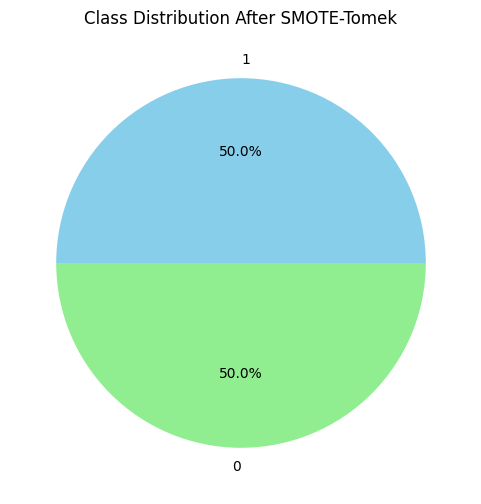

In [ ]:
import matplotlib.pyplot as plt

# Plotting a pie chart to visualize class distribution after balancing
plt.figure(figsize=(6, 6))
resampled_df['Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'])
plt.title('Class Distribution After SMOTE-Tomek')
plt.ylabel('')
plt.show()


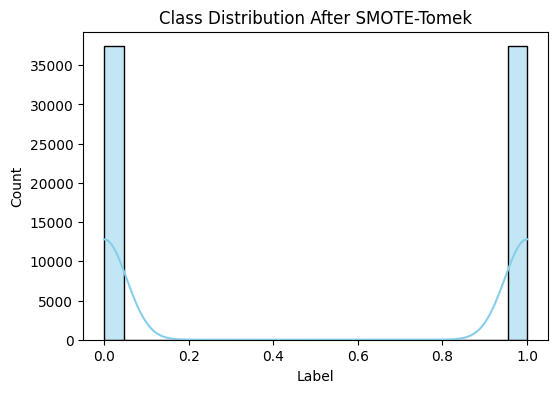

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting a histogram to visualize class distribution after balancing
plt.figure(figsize=(6, 4))
sns.histplot(data=resampled_df, x='Label', kde=True, color='skyblue')
plt.title('Class Distribution After SMOTE-Tomek')
plt.xlabel('Label')
plt.show()
